# PROJ-DIODE-01B: Projection Diode Companion Notebook

**Paper:** *The Projection Diode: Directional Shape Asymmetry Beneath Scalar Reciprocity in a Tesla-Valve Flow Field*  
**Notebook ID:** `PROJ-DIODE-01B`  
**Addendum ID:** `PROJ-DIODE-01A`

This notebook supports the paper by locking the formulas and diagnostic stack.

Important boundary:

$$
\boxed{
\text{This notebook is a metric harness and synthetic witness.}
}
$$

The raw CFD fields used in the paper are not embedded here. If researchers have the forward/reverse velocity or vorticity fields, they can insert them into the metric functions below and reproduce the paper metrics directly.

Paper metric locks:

$$
A_q=-0.005412,
\qquad
P_\omega=0.056802,
\qquad
\Delta M=0.59\ \mathrm{px},
\qquad
\Delta\chi=0.0000.
$$

Core thesis:

$$
\boxed{
A_q\approx0
\quad\text{while}\quad
P_\omega>0.
}
$$


In [1]:
# Cell 1 — Environment setup

import sys
import subprocess
import importlib.util
from pathlib import Path
import math
import random
import time

required = ["numpy", "matplotlib"]
missing = [pkg for pkg in required if importlib.util.find_spec(pkg) is None]
if missing:
    print("Installing missing packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

EPS = 1e-12

PAPER_AQ = -0.005412
PAPER_POMEGA = 0.056802
PAPER_DELTA_M_PX = 0.59
PAPER_DELTA_CHI = 0.0

print("Environment ready.")
print("Paper locks:")
print("A_q       =", PAPER_AQ)
print("P_omega   =", PAPER_POMEGA)
print("Delta M   =", PAPER_DELTA_M_PX, "px")
print("Delta chi =", PAPER_DELTA_CHI)


Environment ready.
Paper locks:
A_q       = -0.005412
P_omega   = 0.056802
Delta M   = 0.59 px
Delta chi = 0.0


## 1. Core Operators

Vorticity:

$$
\omega(x,y)=\frac{\partial v}{\partial x}-\frac{\partial u}{\partial y}.
$$

Horizontal mirror:

$$
R_x[f(x,y)]=f(L-x,y).
$$

Discrete implementation:

$$
R_x[f] = \operatorname{fliplr}(f).
$$


In [2]:
# Cell 2 — Core field operators

def mirror_x(field):
    # Horizontal mirror: R_x[f](x,y) = f(L-x,y).
    return np.fliplr(field)

def vorticity_from_velocity(u, v, dx=1.0, dy=1.0):
    # 2D scalar vorticity omega = dv/dx - du/dy.
    # Arrays are indexed as [y, x].
    dvdx = np.gradient(v, dx, axis=1)
    dudy = np.gradient(u, dy, axis=0)
    return dvdx - dudy

def l2_norm(field):
    return float(np.sqrt(np.sum(np.asarray(field, dtype=float)**2)))

print("Core operators ready.")


Core operators ready.


## 2. Level 1: Scalar Value Read

Eddy burden:

$$
q_T
=
\frac{\sum_{\Omega}\omega^2}
{\sum_{\Omega}(u^2+v^2)+\varepsilon}.
$$

Scalar asymmetry:

$$
A_q
=
\frac{q_{T,R}-q_{T,F}}
{q_{T,R}+q_{T,F}+\varepsilon}.
$$


In [3]:
# Cell 3 — Scalar Value Read

def eddy_burden(omega, u, v, eps=EPS):
    omega = np.asarray(omega, dtype=float)
    u = np.asarray(u, dtype=float)
    v = np.asarray(v, dtype=float)
    return float(np.sum(omega**2) / (np.sum(u**2 + v**2) + eps))

def scalar_asymmetry(qF, qR, eps=EPS):
    return float((qR - qF) / (qR + qF + eps))

print("Scalar Value Read ready.")


Scalar Value Read ready.


## 3. Level 2: Shape / Projection Read

Reciprocal mirror expectation:

$$
\omega_R=-R_x\omega_F.
$$

Projection residual:

$$
P_\omega
=
\frac{\|\omega_R+R_x\omega_F\|_2}
{\|\omega_R\|_2+\|\omega_F\|_2+\varepsilon}.
$$


In [4]:
# Cell 4 — Shape / Projection Read

def projection_residual(omegaF, omegaR, eps=EPS):
    omegaF = np.asarray(omegaF, dtype=float)
    omegaR = np.asarray(omegaR, dtype=float)
    numerator = l2_norm(omegaR + mirror_x(omegaF))
    denominator = l2_norm(omegaR) + l2_norm(omegaF) + eps
    return float(numerator / denominator)

def residual_map(omegaF, omegaR):
    return np.asarray(omegaR, dtype=float) + mirror_x(np.asarray(omegaF, dtype=float))

print("Shape Projection Read ready.")


Shape Projection Read ready.


## 4. Level 3: Spatial Phase / Centroid Read

Vorticity-energy centroid:

$$
M_x^\omega
=
\frac{\sum_{\Omega}x\omega^2}
{\sum_{\Omega}\omega^2+\varepsilon},
\qquad
M_y^\omega
=
\frac{\sum_{\Omega}y\omega^2}
{\sum_{\Omega}\omega^2+\varepsilon}.
$$

Discrete mirror expectation:

$$
M_{x,R}^{expected}=(N_x-1)-M_{x,F}.
$$

Phase shift:

$$
\Delta M=\sqrt{\Delta M_x^2+\Delta M_y^2}.
$$


In [5]:
# Cell 5 — Spatial Phase / Centroid Read

def vorticity_centroid(omega, eps=EPS):
    omega = np.asarray(omega, dtype=float)
    h, w = omega.shape
    yy, xx = np.indices((h, w))
    weight = omega**2
    denom = float(np.sum(weight) + eps)
    mx = float(np.sum(xx * weight) / denom)
    my = float(np.sum(yy * weight) / denom)
    return mx, my

def phase_shift(omegaF, omegaR, eps=EPS):
    omegaF = np.asarray(omegaF, dtype=float)
    omegaR = np.asarray(omegaR, dtype=float)
    h, w = omegaF.shape
    mxF, myF = vorticity_centroid(omegaF, eps)
    mxR, myR = vorticity_centroid(omegaR, eps)
    expected_mxR = (w - 1) - mxF
    dmx = mxR - expected_mxR
    dmy = myR - myF
    dM = float(np.sqrt(dmx**2 + dmy**2))
    return {
        "Mx_F": mxF, "My_F": myF,
        "Mx_R": mxR, "My_R": myR,
        "Mx_R_expected": expected_mxR,
        "Delta_Mx": dmx,
        "Delta_My": dmy,
        "Delta_M": dM,
    }

print("Spatial Phase Read ready.")


Spatial Phase Read ready.


## 5. Level 4: Chirality Read

Positive and negative circulation masses:

$$
\Gamma_+=\sum_{\omega>0}\omega,
\qquad
\Gamma_-^{abs}=\sum_{\omega<0}|\omega|.
$$

Stable implementation:

$$
\chi=\frac{\Gamma_+}{\Gamma_-^{abs}+\varepsilon}.
$$

Directional chirality difference:

$$
\Delta\chi=\chi_F-\chi_R.
$$


In [6]:
# Cell 6 — Chirality Read

def chirality_ratio(omega, eps=EPS):
    omega = np.asarray(omega, dtype=float)
    gamma_plus = float(np.sum(omega[omega > 0]))
    gamma_minus_abs = float(np.sum(np.abs(omega[omega < 0])))
    return float(gamma_plus / (gamma_minus_abs + eps))

def chirality_difference(omegaF, omegaR, eps=EPS):
    chiF = chirality_ratio(omegaF, eps)
    chiR = chirality_ratio(omegaR, eps)
    return {
        "chi_F": chiF,
        "chi_R": chiR,
        "Delta_chi_signed": chiF - chiR,
        "Delta_chi_abs": abs(chiF - chiR),
    }

print("Chirality Read ready.")


Chirality Read ready.


## 6. Unified Diagnostic Function


In [7]:
# Cell 7 — Unified diagnostic stack

def projection_diode_metrics(uF, vF, uR, vR, omegaF=None, omegaR=None, eps=EPS):
    uF = np.asarray(uF, dtype=float)
    vF = np.asarray(vF, dtype=float)
    uR = np.asarray(uR, dtype=float)
    vR = np.asarray(vR, dtype=float)

    if omegaF is None:
        omegaF = vorticity_from_velocity(uF, vF)
    if omegaR is None:
        omegaR = vorticity_from_velocity(uR, vR)

    qF = eddy_burden(omegaF, uF, vF, eps)
    qR = eddy_burden(omegaR, uR, vR, eps)
    Aq = scalar_asymmetry(qF, qR, eps)
    Pomega = projection_residual(omegaF, omegaR, eps)
    phase = phase_shift(omegaF, omegaR, eps)
    chir = chirality_difference(omegaF, omegaR, eps)

    return {
        "qF": qF,
        "qR": qR,
        "Aq": Aq,
        "Pomega": Pomega,
        **phase,
        **chir,
    }

print("Unified metric function ready.")


Unified metric function ready.


## 7. Paper Value Lock

These are the observed values reported by the paper.


In [8]:
# Cell 8 — Paper value lock

paper_metrics = {
    "Aq": PAPER_AQ,
    "Pomega": PAPER_POMEGA,
    "Delta_M": PAPER_DELTA_M_PX,
    "Delta_chi": PAPER_DELTA_CHI,
}

for k, v in paper_metrics.items():
    print(f"{k:12s}: {v}")

assert abs(paper_metrics["Aq"] - (-0.005412)) < 1e-15
assert abs(paper_metrics["Pomega"] - 0.056802) < 1e-15
assert abs(paper_metrics["Delta_M"] - 0.59) < 1e-15
assert abs(paper_metrics["Delta_chi"] - 0.0) < 1e-15

print("Paper values locked.")


Aq          : -0.005412
Pomega      : 0.056802
Delta_M     : 0.59
Delta_chi   : 0.0
Paper values locked.


## 8. Synthetic Projection-Diode Witness

This synthetic model is **not** the paper CFD field.

It proves the diagnostic logic:

$$
A_q\approx0
\quad\text{can coexist with}\quad
P_\omega>0.
$$

The synthetic reverse field is built as:

$$
\omega_R=-R_x\omega_F+\alpha T,
$$

where $T$ is a localized route-memory perturbation. The perturbation amplitude $\alpha$ is tuned to match the paper's $P_\omega$.


In [9]:
# Cell 9 — Synthetic field construction

def gaussian_2d(h, w, cx, cy, sx, sy, amp=1.0):
    yy, xx = np.indices((h, w))
    return amp * np.exp(-(((xx - cx)**2) / (2*sx**2) + ((yy - cy)**2) / (2*sy**2)))

def make_forward_vorticity(h=96, w=192):
    omega = np.zeros((h, w), dtype=float)
    omega += gaussian_2d(h, w, 50, 32, 12, 8, amp=1.0)
    omega -= gaussian_2d(h, w, 78, 58, 14, 9, amp=0.95)
    omega += gaussian_2d(h, w, 112, 42, 10, 10, amp=0.70)
    omega -= gaussian_2d(h, w, 142, 64, 13, 8, amp=0.72)
    omega += 0.10 * np.sin(np.linspace(0, 4*np.pi, w))[None, :] * np.exp(-((np.arange(h)[:, None]-48)**2)/(2*30**2))
    return omega

def make_route_memory_trace(h=96, w=192):
    trace = np.zeros((h, w), dtype=float)
    trace += gaussian_2d(h, w, 116, 28, 10, 7, amp=1.0)
    trace -= gaussian_2d(h, w, 128, 60, 11, 9, amp=1.0)
    trace += gaussian_2d(h, w, 152, 44, 8, 8, amp=0.65)
    trace -= gaussian_2d(h, w, 92, 72, 9, 7, amp=0.65)
    return trace

def tune_trace_amplitude(omegaF, trace, target_P, iterations=60):
    lo, hi = 0.0, 10.0
    baseR = -mirror_x(omegaF)
    for _ in range(iterations):
        mid = (lo + hi) / 2
        omegaR = baseR + mid * trace
        val = projection_residual(omegaF, omegaR)
        if val < target_P:
            lo = mid
        else:
            hi = mid
    alpha = (lo + hi) / 2
    omegaR = baseR + alpha * trace
    return alpha, omegaR

def make_velocity_fields_for_target_Aq(omegaF, omegaR, target_Aq=PAPER_AQ):
    h, w = omegaF.shape
    n = h * w
    qF_target = 1.0
    r = (1 + target_Aq) / (1 - target_Aq)
    qR_target = r * qF_target
    EF = float(np.sum(omegaF**2))
    ER = float(np.sum(omegaR**2))
    speedF = math.sqrt(EF / (qF_target * n))
    speedR = math.sqrt(ER / (qR_target * n))
    uF = np.full_like(omegaF, speedF)
    vF = np.zeros_like(omegaF)
    uR = np.full_like(omegaR, speedR)
    vR = np.zeros_like(omegaR)
    return uF, vF, uR, vR

omegaF_syn = make_forward_vorticity()
trace_syn = make_route_memory_trace()
alpha, omegaR_syn = tune_trace_amplitude(omegaF_syn, trace_syn, PAPER_POMEGA)
uF_syn, vF_syn, uR_syn, vR_syn = make_velocity_fields_for_target_Aq(omegaF_syn, omegaR_syn, PAPER_AQ)

metrics_syn = projection_diode_metrics(uF_syn, vF_syn, uR_syn, vR_syn, omegaF_syn, omegaR_syn)

print("Synthetic route-memory amplitude alpha:", alpha)
for key in ["qF", "qR", "Aq", "Pomega", "Delta_M", "Delta_chi_signed", "Delta_chi_abs"]:
    print(f"{key:18s}: {metrics_syn[key]}")

assert abs(metrics_syn["Aq"] - PAPER_AQ) < 1e-9
assert abs(metrics_syn["Pomega"] - PAPER_POMEGA) < 1e-9

print("Synthetic projection-diode witness generated.")


Synthetic route-memory amplitude alpha: 0.14146728236285705
qF                : 0.9999999999999993
qR                : 0.9892342641623522
Aq                : -0.005411999999997544
Pomega            : 0.056801999999999984
Delta_M           : 2.2294621226622753
Delta_chi_signed  : -0.26091360639463346
Delta_chi_abs     : 0.26091360639463346
Synthetic projection-diode witness generated.


## 9. Straight-Channel Null Control

For exact reciprocity:

$$
\omega_R=-R_x\omega_F.
$$

Expected:

$$
P_\omega=0.
$$


In [10]:
# Cell 10 — Straight-channel null control

omegaR_null = -mirror_x(omegaF_syn)
uF_null, vF_null, uR_null, vR_null = make_velocity_fields_for_target_Aq(omegaF_syn, omegaR_null, target_Aq=0.0)

metrics_null = projection_diode_metrics(uF_null, vF_null, uR_null, vR_null, omegaF_syn, omegaR_null)

for key in ["Aq", "Pomega", "Delta_M", "Delta_chi_signed", "Delta_chi_abs"]:
    print(f"{key:18s}: {metrics_null[key]}")

assert abs(metrics_null["Aq"]) < 1e-9
assert metrics_null["Pomega"] < 1e-12
assert metrics_null["Delta_M"] < 1e-9

print("Straight-channel null control passed.")


Aq                : -1.6653345369369035e-16
Pomega            : 0.0
Delta_M           : 1.4228607195221903e-13
Delta_chi_signed  : -0.27776709994453286
Delta_chi_abs     : 0.27776709994453286
Straight-channel null control passed.


## 10. Scalar Blindness Demonstration

The scalar channel can be forced near zero while the shape channel remains nonzero.

$$
A_q\approx0
\quad\wedge\quad
P_\omega>0.
$$


In [11]:
# Cell 11 — Scalar blindness demonstration

uF_blind, vF_blind, uR_blind, vR_blind = make_velocity_fields_for_target_Aq(omegaF_syn, omegaR_syn, target_Aq=0.0)

metrics_blind = projection_diode_metrics(uF_blind, vF_blind, uR_blind, vR_blind, omegaF_syn, omegaR_syn)

for key in ["Aq", "Pomega", "Delta_M", "Delta_chi_signed", "Delta_chi_abs"]:
    print(f"{key:18s}: {metrics_blind[key]}")

assert abs(metrics_blind["Aq"]) < 1e-9
assert metrics_blind["Pomega"] > 0.01

print("Scalar blindness demonstration passed.")


Aq                : -1.1102230246246024e-16
Pomega            : 0.056801999999999984
Delta_M           : 2.2294621226622753
Delta_chi_signed  : -0.26091360639463346
Delta_chi_abs     : 0.26091360639463346
Scalar blindness demonstration passed.


## 11. Convergence and Z-Score Scaffold

Control distribution:

$$
P_\omega^{(i)}\sim\mathcal{D}_{control}.
$$

Z-score:

$$
Z=
\frac{P_{\omega,\mathrm{Tesla}}-\mu_{control}}
{\sigma_{control}+\varepsilon}.
$$

Strong confirmation criterion:

$$
Z>5.
$$


In [12]:
# Cell 12 — Z-score scaffold with synthetic null perturbations

def noisy_reciprocal_control(omegaF, noise_scale=0.002, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    return -mirror_x(omegaF) + rng.normal(0.0, noise_scale, size=omegaF.shape)

rng = np.random.default_rng(12345)
control_values = []

for _ in range(100):
    omegaR_c = noisy_reciprocal_control(omegaF_syn, noise_scale=0.002, rng=rng)
    control_values.append(projection_residual(omegaF_syn, omegaR_c))

control_values = np.array(control_values)
mu_control = float(np.mean(control_values))
sigma_control = float(np.std(control_values, ddof=1))
Z = (metrics_syn["Pomega"] - mu_control) / (sigma_control + EPS)

print("Synthetic control mean Pomega:", mu_control)
print("Synthetic control std Pomega: ", sigma_control)
print("Synthetic projection diode Pomega:", metrics_syn["Pomega"])
print("Synthetic Z-score:", Z)

assert Z > 5.0
print("Synthetic Z-score criterion passed.")


Synthetic control mean Pomega: 0.004106151520473555
Synthetic control std Pomega:  2.0412089351002475e-05
Synthetic projection diode Pomega: 0.056801999999999984
Synthetic Z-score: 2581.5998054769752
Synthetic Z-score criterion passed.


## 12. Visualization


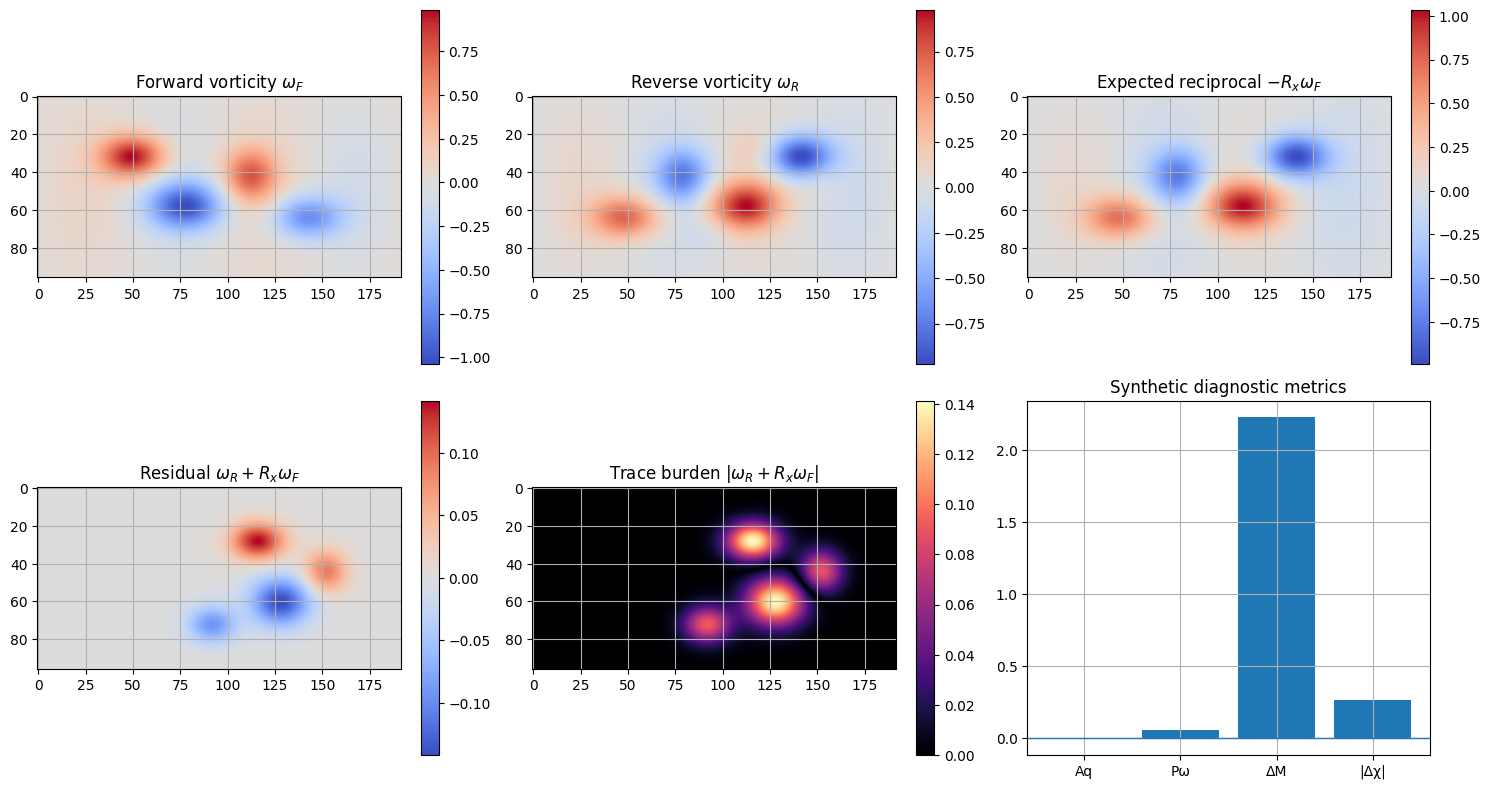

In [13]:
# Cell 13 — Visualize synthetic witness

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

im0 = axes[0,0].imshow(omegaF_syn, cmap="coolwarm")
axes[0,0].set_title("Forward vorticity $\\omega_F$")
plt.colorbar(im0, ax=axes[0,0], fraction=0.046)

im1 = axes[0,1].imshow(omegaR_syn, cmap="coolwarm")
axes[0,1].set_title("Reverse vorticity $\\omega_R$")
plt.colorbar(im1, ax=axes[0,1], fraction=0.046)

im2 = axes[0,2].imshow(-mirror_x(omegaF_syn), cmap="coolwarm")
axes[0,2].set_title("Expected reciprocal $-R_x\\omega_F$")
plt.colorbar(im2, ax=axes[0,2], fraction=0.046)

err = residual_map(omegaF_syn, omegaR_syn)
im3 = axes[1,0].imshow(err, cmap="coolwarm")
axes[1,0].set_title("Residual $\\omega_R+R_x\\omega_F$")
plt.colorbar(im3, ax=axes[1,0], fraction=0.046)

im4 = axes[1,1].imshow(np.abs(err), cmap="magma")
axes[1,1].set_title("Trace burden $|\\omega_R+R_x\\omega_F|$")
plt.colorbar(im4, ax=axes[1,1], fraction=0.046)

labels = ["Aq", "Pω", "ΔM", "|Δχ|"]
vals = [metrics_syn["Aq"], metrics_syn["Pomega"], metrics_syn["Delta_M"], metrics_syn["Delta_chi_abs"]]
axes[1,2].bar(labels, vals)
axes[1,2].set_title("Synthetic diagnostic metrics")
axes[1,2].axhline(0, linewidth=1)

plt.tight_layout()
plt.show()


## 13. Raw CFD Data Insertion Point

To use this notebook with actual CFD data, replace the synthetic arrays with real arrays:

```python
uF = ...
vF = ...
uR = ...
vR = ...
omegaF = vorticity_from_velocity(uF, vF, dx, dy)
omegaR = vorticity_from_velocity(uR, vR, dx, dy)

metrics = projection_diode_metrics(uF, vF, uR, vR, omegaF, omegaR)
```

Expected paper comparison:

$$
A_q=-0.005412,
\qquad
P_\omega=0.056802,
\qquad
\Delta M=0.59\ \mathrm{px},
\qquad
\Delta\chi=0.0000.
$$


In [14]:
# Cell 14 — Final validation summary

checks = {
    "paper_Aq_locked": abs(PAPER_AQ - (-0.005412)) < 1e-15,
    "paper_Pomega_locked": abs(PAPER_POMEGA - 0.056802) < 1e-15,
    "paper_DeltaM_locked": abs(PAPER_DELTA_M_PX - 0.59) < 1e-15,
    "paper_DeltaChi_locked": abs(PAPER_DELTA_CHI - 0.0) < 1e-15,
    "null_projection_residual_zero": metrics_null["Pomega"] < 1e-12,
    "scalar_blindness": abs(metrics_blind["Aq"]) < 1e-9 and metrics_blind["Pomega"] > 0.01,
    "synthetic_matches_Aq": abs(metrics_syn["Aq"] - PAPER_AQ) < 1e-9,
    "synthetic_matches_Pomega": abs(metrics_syn["Pomega"] - PAPER_POMEGA) < 1e-9,
    "synthetic_Z_gt_5": Z > 5.0,
}

print("FINAL VALIDATION")
print("=" * 80)
for name, ok in checks.items():
    print(f"{name:35s}: {ok}")

assert all(checks.values())

print()
print("PROJ-DIODE-01B validation complete.")
print("Core lock: value can cancel while shape remains direction-dependent.")


FINAL VALIDATION
paper_Aq_locked                    : True
paper_Pomega_locked                : True
paper_DeltaM_locked                : True
paper_DeltaChi_locked              : True
null_projection_residual_zero      : True
scalar_blindness                   : True
synthetic_matches_Aq               : True
synthetic_matches_Pomega           : True
synthetic_Z_gt_5                   : True

PROJ-DIODE-01B validation complete.
Core lock: value can cancel while shape remains direction-dependent.


## 14. Final Formula Stack

$$
\Delta:
\quad
\omega(x,y)
=
\frac{\partial v}{\partial x}
-
\frac{\partial u}{\partial y}
$$

$$
\oplus:
\quad
q_T
=
\frac{\sum_{\Omega}\omega^2}
{\sum_{\Omega}(u^2+v^2)+\varepsilon}
$$

$$
↻:
\quad
A_q
=
\frac{q_{T,R}-q_{T,F}}
{q_{T,R}+q_{T,F}+\varepsilon}
$$

$$
\bot:
\quad
P_\omega
=
\frac{\|\omega_R+R_x\omega_F\|_2}
{\|\omega_R\|_2+\|\omega_F\|_2+\varepsilon}
$$

$$
\Psi:
\quad
A_q\approx0
\quad\wedge\quad
P_\omega>0
$$

Final lock:

$$
\boxed{
\text{Value can cancel while shape remains direction-dependent.}
}
$$
